In [1]:
import numpy as np
from PIL import Image
import taichi as ti
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from utils import run_optimization, resample_polyline, get_area

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


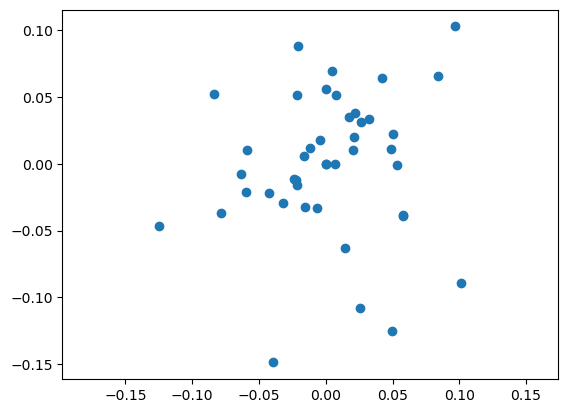

In [40]:
def init_trajectory(control_point_num):  # 生成初始轨迹
    xs, ys, rotations = resample_polyline([
        [0, 0, 0],
        [0, 0, 2 * np.pi]
    ], control_point_num).T
    return xs, ys, rotations

xs, ys, rotations = init_trajectory(  # 初始轨迹
    control_point_num=43,  # 轨迹的控制点数量
)

xs[1:-1] += np.random.randn(len(xs) - 2) * 0.05
ys[1:-1] += np.random.randn(len(ys) - 2) * 0.05

plt.scatter(xs, ys)
plt.axis('equal')
pass

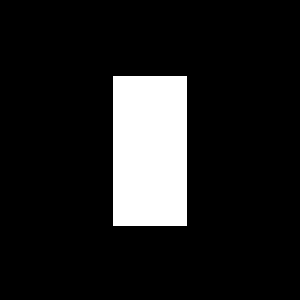

In [41]:
# 可视化墙（白色区域为墙）

from utils import test_forbidden_function

normal_0 = ti.Vector([1., 0.])
normal_1 = ti.Vector([0., 1.])
normal_2 = ti.Vector([-1., 0.])
normal_3 = ti.Vector([0., -1.])
edge_distance_1 = 0.5 * 0.5
edge_distance_2 = 0.5
@ti.func
def is_forbidden(x1, y1, x2, y2):  # 指定哪里是墙
    v = ti.Vector([x2, y2])
    return ti.math.dot(v, normal_0) < edge_distance_1 and ti.math.dot(v, normal_1) < edge_distance_2 and ti.math.dot(v, normal_2) < edge_distance_1 and ti.math.dot(v, normal_3) < edge_distance_2  # 长方形内是墙

image = test_forbidden_function(
    is_forbidden,
    -1, 1, -1, 1, [300, 300],
    # wall_normal=[0, 0.05]
)
Image.fromarray(np.array(image.T[::-1] * 255, dtype=np.uint8))

In [ ]:
xs, ys, rotations = np.load('../trajectory/能让长方形旋转一周的房间_宽长比0.5_3/sofa_200.npy')

In [276]:
xs = zoom(xs, zoom=1 / 8, order=1)
ys = zoom(ys, zoom=1 / 8, order=1)
rotations = zoom(rotations, zoom=1 / 8, order=1)

xs[-1] = xs[0]  # 这三行代码只是为了应对插值的bug，目前插值函数有很低的概率导致最后一项是0
ys[-1] = ys[0]
rotations[-1] = 2 * np.pi

In [61]:
0.973985 / 0.9817

0.9921411836609962

(-0.08391744869479693,
 0.08460709972570932,
 -0.04317689798706537,
 0.04264342324025706)

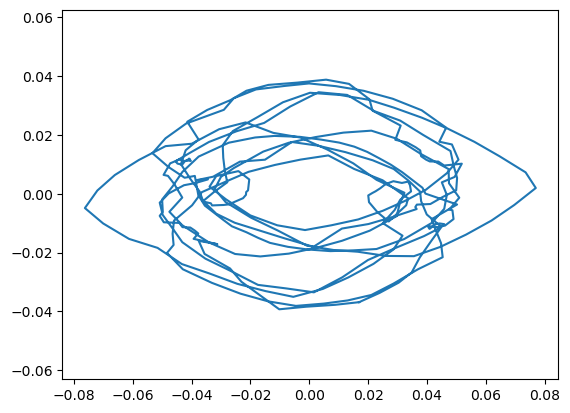

In [59]:
plt.plot(xs, ys)
plt.axis('equal')

Initial survivors: 1.2819328308105469
iter 500 / 10000, maximal_area=1.2819843292236328
iter 1000 / 10000, maximal_area=1.2820208072662354
iter 1500 / 10000, maximal_area=1.2820637226104736
iter 2000 / 10000, maximal_area=1.2821044921875
iter 2500 / 10000, maximal_area=1.2821409702301025
iter 3000 / 10000, maximal_area=1.282179594039917
iter 3500 / 10000, maximal_area=1.2822117805480957
iter 4000 / 10000, maximal_area=1.282231092453003
iter 4500 / 10000, maximal_area=1.2822482585906982
iter 5000 / 10000, maximal_area=1.2822761535644531
iter 5500 / 10000, maximal_area=1.282301902770996
iter 6000 / 10000, maximal_area=1.2823362350463867
iter 6500 / 10000, maximal_area=1.2823727130889893
iter 7000 / 10000, maximal_area=1.2823963165283203
iter 7500 / 10000, maximal_area=1.282430648803711
iter 8000 / 10000, maximal_area=1.2824499607086182
iter 8500 / 10000, maximal_area=1.282456398010254
iter 9000 / 10000, maximal_area=1.2824585437774658
iter 9500 / 10000, maximal_area=1.2824757099151611
it

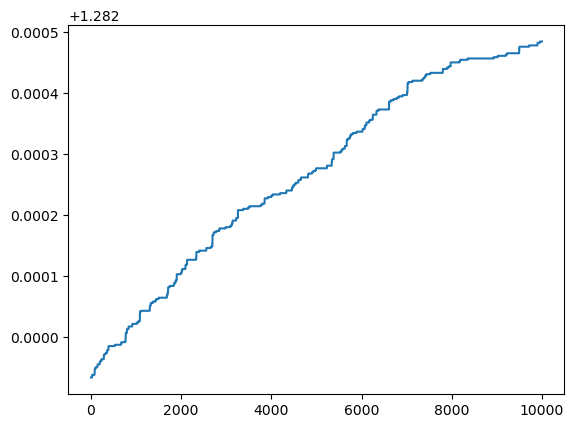

In [57]:
sofa_w, sofa_h = 1.5, 1.5   # 求解域的尺寸

best_score, xs, ys, rotations, sofa, maximal_area_record = run_optimization(
    is_forbidden,
    # xs,  # 上采样使得轨迹分辨率翻倍时注释掉这三行
    # ys,
    # rotations,
    initial_xs=zoom(xs, zoom=2, order=1),  # 保持轨迹分辨率时注释掉这三行
    initial_ys=zoom(ys, zoom=2, order=1),
    initial_rotations=zoom(rotations, zoom=2, order=1),
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    mutation_sigma_pos = 0.002,  # 变异率 0.002
    mutation_sigma_rotation = 0,  # 变异率
    iterations = 10000,  # 10000
    trajectory_upsampling=41,  # 41 101
    resolution=1024,  # 1024 2000
    print_every=500,  # 1000
    save_image_every=100,
    save_image_path='../images/能让长方形旋转一周的房间_宽长比0.5_3/sofa_',
    save_image_start_id=400,  # 文件起始标号
    save_trajectory_path='../trajectory/能让长方形旋转一周的房间_宽长比0.5_3/sofa_',
    boundary_conditions='periodic'  # 循环边界条件
)
print(f"Estimated maximal sofa area (by sampling): {best_score:.5f}")
# save mask image as PNG if pillow is available

img = (sofa * 255).astype(np.uint8)
im = Image.fromarray(img.T[::-1])
im.save('../sofa_survivors.png')
plt.plot(maximal_area_record)

In [58]:
from utils import get_area

best_score = get_area(is_forbidden, xs, ys, rotations, sofa_w, sofa_h, resolution=5000, trajectory_upsampling=200)  # 以很高的分辨率计算面积

area = sofa_w * sofa_h - best_score  # 房间面积
area_disk = np.pi * (edge_distance_1 ** 2 + edge_distance_2 ** 2)  # 圆的面积
area / area_disk
f'{area} / {area_disk} = {area / area_disk}'

'0.9680401086807251 / 0.9817477042468103 = 0.9860375578096191'

| 宽长比       | 优势形态         |
| ------------ | ---------------- |
| 0.02 ~ 0.463 | 三次旋转对称图形 |
| 0.5 ~ 0.7    | ？               |
| 0.8 ~ 1      | 五次旋转对称图形 |

